# Optimization

In this notebook we'll explore some optimizations we can make in order to speed up the computation of specific methods while generating artificial cells.



In [1]:
import numpy as np
import time

Make sure to run `pip install -e .` before running the cell below. This command will make sure `diet4cola` is installed as a module in your current Python/Conda environment.

In [2]:
from diet4cola.noise import *
from diet4cola.utils import *

In [3]:
def summary(data: np.ndarray,
            start: float,
            end: float,
            is_fast: bool,
            seed: int):
    print(f'Computing worley-noise ({'FAST' if is_fast else 'SLOW'}) took {(end - start):.3f}s')
    plot_2d_array(data, f'Worley-Noise ({'Fast' if is_fast else 'Slow'}, Seed={seed})', 'gray', 0, 1)

## Worley Noise

Worley noise can take an extremely long time, especially when the number of points starts increasing. To optimize this, we can use a spatial subdivision structure that aims to reduce query times in n-D space. We start by benchmarking the slow worley noise method for 2048 points on a (512 x 512) grid.

In [4]:
width = 512
height = 512
points = 2048
seed = 1

In [5]:
worley_slow_start = time.perf_counter()
#worley_slow = worley_noise(width, height, points, seed)
worley_slow_end = time.perf_counter()

In [6]:
#summary(worley_slow, worley_slow_start, worley_slow_end, False, seed)

In [7]:
worley_fast_start = time.perf_counter()
worley_fast = worley_noise_kd(width, height, points, seed)
worley_fast_end = time.perf_counter()

Computing worley-noise (FAST) took 0.083s


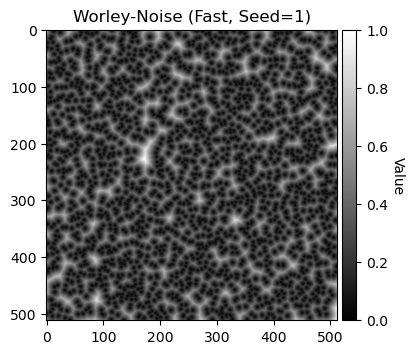

In [8]:
summary(worley_fast, worley_fast_start, worley_fast_end, True, seed)

This simple optimization allows for an $\approx$ 157x increase in speed. Well worth the investment!

## Spot Noise

Spot noise is a type of noise function that is extensively used by both the myosin and actin noise functions and often requires significant amount of compute time.

In [45]:
spot_slow_start = time.perf_counter()
spot_slow = spot_noise(width, height, 512, 0.005, 1, seed)
spot_slow_end = time.perf_counter()

Computing worley-noise (SLOW) took 3.754s


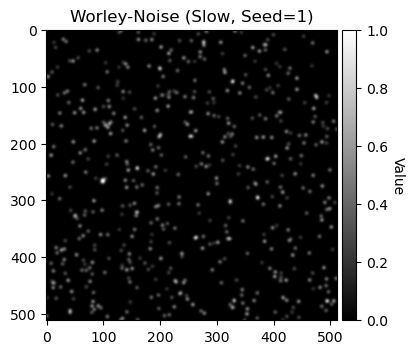

In [46]:
summary(spot_slow, spot_slow_start, spot_slow_end, False, seed)

In [ ]:
spot_fast_start = time.perf_counter()
spot_fast = spot_noise_convolved(width, height, 512, 2.75, 1, seed)
spot_fast_end = time.perf_counter()

Computing worley-noise (FAST) took 0.004s


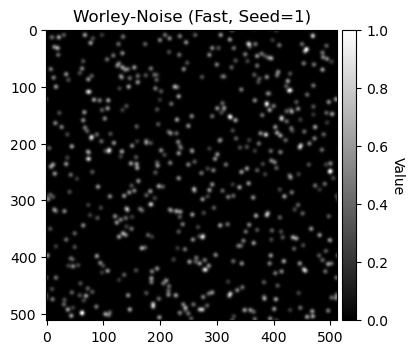

In [56]:
summary(spot_fast, spot_fast_start, spot_fast_end, True, seed)

While the sigma scaling is inverted in some way, the quality remains the same for a fraction of the time required. 